In [8]:
import torch
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
class MotionDetection(nn.Module):
    def __init__(self, weights=None, signs=None, num_types=9, t4_indices=None, t5_indices=None):
        super().__init__()
        num_types = weights.shape[0] if weights is not None else num_types # infer neuron-type count from the connectome matrix instead of hardcoding 9
        self.num_types = num_types
        self.t4_indices = t4_indices if t4_indices is not None else [7] # column(s) of the T4 subtype(s) among the neuron types
        self.t5_indices = t5_indices if t5_indices is not None else [8] # column(s) of the T5 subtype(s) among the neuron types
        self.weights = nn.Parameter(torch.zeros((num_types, num_types))) if weights is None else nn.Parameter(weights) # initialize weights to zero
        self.register_buffer('weights_sign', torch.zeros((num_types, 1))) if signs is None else self.register_buffer('weights_sign', signs) # initialize weights sign buffer to zero
        self.leak_weights = nn.Parameter(torch.ones((num_types,)) * 2) # start with a strong decay bias so potential doesn't saturate before the stimulus has influence

        # use the connectome's relative structure (which type-pairs are strongly/weakly connected) as a shared
        # starting shape for the lateral pathways instead of a flat constant, normalized to the same ~0.1
        # magnitude as the noise below so it doesn't reintroduce the saturation the -3 base fixed. Falls back
        # to no structure (flat -3) when no real connectome weights are provided.
        if weights is not None:
            centered = weights - weights.mean()
            structured_bias = centered / (centered.std() + 1e-8) * 0.1
        else:
            structured_bias = torch.zeros((num_types, num_types))

        # -3 base keeps the recurrent dynamics stable (this is what gave the clean loss curve); the
        # connectome-shaped bias is shared by both sides so it doesn't break symmetry on its own - the
        # independent per-side noise is still what lets gradient descent tell left and right apart
        self.weights_left = nn.Parameter(torch.full((num_types, num_types), -3.0) + structured_bias + torch.randn(num_types, num_types) * 0.1)
        self.weights_right = nn.Parameter(torch.full((num_types, num_types), -3.0) + structured_bias + torch.randn(num_types, num_types) * 0.1)
            
    def _total_input(self, potential, output, weights, leak_weights, weights_left, weights_right, zero_column):
        # potential is a tensor of shape (batch_size, 16, num_types) that represents the current state of the network
        # output is a tensor of shape (batch_size, 16, num_types) that represents the output of the network after applying the tanh activation function
        # weights is a tensor of shape (num_types, num_types)
        # zero_column is a tensor of shape (batch_size, 1, num_types), preallocated once per forward call and reused every timestep
        
        # output_left is a tensor of shape (batch_size, 16, num_types) with the left neighbor of each neuron
        output_left = torch.cat((zero_column, output[:, :-1, :]), dim=1) # drop the last column to get the left neighbor
        # output_right is a tensor of shape (batch_size, 16, num_types) with the right neighbor of each neuron
        output_right = torch.cat((output[:, 1:, :], zero_column), dim=1) # drop the first column to get the right neighbor
        
        # integrate
        # new state is a tensor of shape (batch_size, 16, num_types) - this tells us the total input to each neuron in the network
        integrate_contribution = torch.matmul(output, weights) + torch.matmul(output_left, weights_left) + torch.matmul(output_right, weights_right)

        # leak/decay
        # leak_weights is a tensor of shape (num_types,) that represents the leak/decay of each neuron in the network
        decay_contribution = potential * leak_weights # element-wise multiplication to get the decay contribution of each neuron

        return (potential - decay_contribution) + integrate_contribution # subtract the decay contribution from the total input to get the next state of the network
    
    def forward(self, stimulus): # stimulus is a tensor of shape (batch_size, T, 16), where T is the number of time steps
        batch_size = stimulus.shape[0]
        potential = torch.zeros((batch_size, 16, self.num_types)) # initialize the state to zero
        output = torch.tanh(potential) # apply the tanh activation function to the state
        
        weights_signed = F.softplus(self.weights) * self.weights_sign # apply the sign of the weights to the weights
        weights_signed_left = F.softplus(self.weights_left) * self.weights_sign # apply the sign of the left weights to the left weights
        weights_signed_right = F.softplus(self.weights_right) * self.weights_sign # apply the sign of the right weights to the right weights
        leak_weights_constrained = torch.sigmoid(self.leak_weights) # apply the sigmoid function to the

        # preallocate once and reuse every timestep instead of recreating these on every one of the T iterations
        zero_column = torch.zeros(batch_size, 1, self.num_types)
        stimulus_add = torch.zeros((batch_size, 16, self.num_types)) # only column 0 is ever written; columns 1: stay zero throughout
        
        for t in range(stimulus.shape[1]): # iterate over time steps
            stimulus_add[:, :, 0] = stimulus[:, t, :] # overwrite the stimulus contribution in place
            potential = self._total_input(potential, output, weights_signed, leak_weights_constrained, weights_signed_left, weights_signed_right, zero_column) # get the next state
            potential = potential + stimulus_add # add the stimulus to the state
            output = torch.tanh(potential) # apply the tanh activation function to the state
        
        # readout from all T4 subtype neurons, summed across positions and subtypes
        t4_readout = torch.sum(output[:, :, self.t4_indices], dim=(1, 2))
        # readout from all T5 subtype neurons, summed across positions and subtypes
        t5_readout = torch.sum(output[:, :, self.t5_indices], dim=(1, 2))
        return torch.sigmoid(t4_readout + t5_readout) # return the sum of the T4 and T5 readouts
        

In [10]:
def train_model_one_epoch(model, dataloader, optimizer, criterion):
    model.train(True) # set the model to training mode
    total_loss = 0.0 # initialize the total loss
    total_correct = 0 # initialize the count of correctly classified directional samples
    total_counted = 0 # initialize the count of samples with a definite direction label

    for batch in dataloader: # iterate over batches
        optimizer.zero_grad() # zero the gradients
        stimulus, labels = batch # unpack the batch
        output = model(stimulus) # get the model output
        loss = criterion(output, labels) # compute the loss
        loss.backward() # backpropagate the loss
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # clip exploding gradients from the recurrent unroll
        optimizer.step() # update the model parameters
        total_loss += loss.item() # accumulate the loss

        # accuracy only over samples with a definite direction (0.5 = static has no "correct" class to grade against)
        mask = labels != 0.5
        if mask.any():
            predicted = (output[mask] > 0.5).float()
            total_correct += (predicted == labels[mask]).sum().item()
            total_counted += mask.sum().item()

    loss_per_batch = total_loss / len(dataloader) # compute the average loss per batch
    accuracy = total_correct / total_counted if total_counted > 0 else float("nan") # compute the epoch's directional accuracy
    return loss_per_batch, accuracy # return the loss and accuracy for the epoch

def train_model(model, dataloader, optimizer, criterion, num_epochs):
    loss_per_epoch = [] # initialize a list to store the loss for each epoch
    accuracy_per_epoch = [] # initialize a list to store the accuracy for each epoch
    for epoch in range(num_epochs): # iterate over epochs
        loss_per_batch, accuracy = train_model_one_epoch(model, dataloader, optimizer, criterion) # train the model for one epoch
        print(f"Epoch {epoch+1}/{num_epochs} completed, loss: {loss_per_batch:.4f}, accuracy: {accuracy:.4f}.") # print the epoch number
        loss_per_epoch.append(loss_per_batch) # append the loss for the epoch to the list
        accuracy_per_epoch.append(accuracy) # append the accuracy for the epoch to the list
    return loss_per_epoch, accuracy_per_epoch # return the lists of losses and accuracies for each epoch

In [11]:
# import weights and signs from neuprint
type_matrix_df = pd.read_csv('type_matrix.csv', index_col=0) # keep the DataFrame so we still have the neuron type names
signs = pd.read_csv('sign_matrix.csv', index_col=0).values # import the signs from the sign matrix

# find which columns are T4/T5 subtypes so the readout generalizes to however many there are
type_names = list(type_matrix_df.columns)
t4_indices = [i for i, name in enumerate(type_names) if name.startswith('T4')]
t5_indices = [i for i, name in enumerate(type_names) if name.startswith('T5')]

# create a weights matrix based on the weights
weights = torch.tensor(type_matrix_df.values).float() # cast to float32 to match the rest of the model's tensors
signs = torch.tensor(signs).float() # cast to float32 to match the rest of the model's tensors
# normalize so the total input any neuron can receive (summed across its input types) is bounded by 1,
# not just the single largest weight - keeps the 24-step recurrent unroll from saturating tanh/sigmoid
weights = weights / weights.abs().sum(dim=0).max()

In [12]:
from torch.utils.data import DataLoader
from stimulus_generator import SyntheticMotionDataset

batch_size = 128 # bigger batch amortizes per-timestep Python/dispatch overhead better
num_batches_per_epoch = 1000 # unchanged from the batch_size=32 setup (10000 // 32), so epochs stay comparable to earlier runs
train_dataset = SyntheticMotionDataset(num_batches=num_batches_per_epoch, batch_size=batch_size, T=24, width=16)
# batch_size=None tells DataLoader each item from the dataset is already a full batch (no further collation needed);
# num_workers generates batches on separate CPU processes in parallel with training
dataloader = DataLoader(train_dataset, batch_size=None, num_workers=2, persistent_workers=True)

Output on all-zero stimulus - mean: 0.5000, std: 0.0000, min: 0.5000, max: 0.5000
Output on untrained, real stimulus - mean: 0.1424, std: 0.2479, min: 0.0000, max: 0.9031
First 10 predictions vs labels: [(1.3528761883208062e-05, 0.5), (1.3523139386961702e-05, 1.0), (8.612997589807492e-06, 0.0), (1.3520313586923294e-05, 0.0), (1.3511897122953087e-05, 1.0), (0.4418452978134155, 0.0), (1.3529691386793274e-05, 0.5), (1.35296531880158e-05, 0.5), (0.10779894888401031, 1.0), (1.3519527783500962e-05, 1.0)]
Epoch 1/50 completed, loss: 0.7539, accuracy: 0.5015.
Epoch 2/50 completed, loss: 0.6959, accuracy: 0.4979.
Epoch 3/50 completed, loss: 0.6953, accuracy: 0.5021.
Epoch 4/50 completed, loss: 0.6952, accuracy: 0.4981.
Epoch 5/50 completed, loss: 0.6951, accuracy: 0.4971.
Epoch 6/50 completed, loss: 0.6946, accuracy: 0.5005.
Epoch 7/50 completed, loss: 0.6944, accuracy: 0.5003.
Epoch 8/50 completed, loss: 0.6942, accuracy: 0.5036.
Epoch 9/50 completed, loss: 0.6940, accuracy: 0.5015.
Epoch 10/5

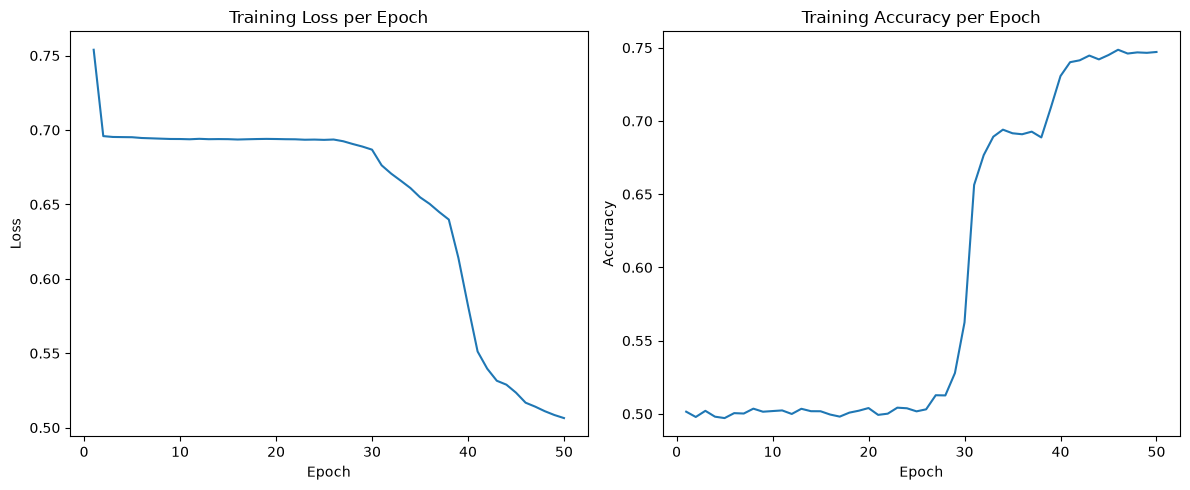

In [14]:
model = MotionDetection(weights, signs, t4_indices=t4_indices, t5_indices=t5_indices) # create an instance of the model

# diagnostic: does the model saturate even with no stimulus at all? if so, the recurrent
# dynamics have a fixed point that dominates the actual input, regardless of direction.
with torch.no_grad():
    zero_stimulus = torch.zeros((batch_size, 24, 16))
    zero_output = model(zero_stimulus)
    print(f"Output on all-zero stimulus - mean: {zero_output.mean():.4f}, std: {zero_output.std():.4f}, min: {zero_output.min():.4f}, max: {zero_output.max():.4f}")

# diagnostic: does the untrained model already saturate on real (non-zero) stimulus, before any
# training happens? if so, the recurrent dynamics blow up on real input regardless of learning.
# if this looks reasonable but training degrades it, the problem is in optimization, not dynamics.
with torch.no_grad():
    real_stimulus, real_labels = next(iter(dataloader))
    real_output = model(real_stimulus)
    print(f"Output on untrained, real stimulus - mean: {real_output.mean():.4f}, std: {real_output.std():.4f}, min: {real_output.min():.4f}, max: {real_output.max():.4f}")
    print(f"First 10 predictions vs labels: {list(zip(real_output[:10].tolist(), real_labels[:10].tolist()))}")

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # create an Adam optimizer
criterion = nn.BCELoss() # create a binary cross entropy loss function with logits
num_epochs = 50 # set the number of epochs to train for

loss_per_epoch, accuracy_per_epoch = train_model(model, dataloader, optimizer, criterion, num_epochs) # train the model and get the loss/accuracy for each epoch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) # set the size of the figure

ax1.plot(range(1, num_epochs + 1), loss_per_epoch) # plot the loss per epoch
ax1.set_xlabel("Epoch") # label the x-axis
ax1.set_ylabel("Loss") # label the y-axis
ax1.set_title("Training Loss per Epoch") # set the title of the plot

ax2.plot(range(1, num_epochs + 1), accuracy_per_epoch) # plot the accuracy per epoch
ax2.set_xlabel("Epoch") # label the x-axis
ax2.set_ylabel("Accuracy") # label the y-axis
ax2.set_title("Training Accuracy per Epoch") # set the title of the plotwWw

plt.tight_layout()
plt.show() # display the plot